In [1]:
import numpy as np
import matplotlib.pyplot as plt
import flpoAgent
import importlib
import random
from scipy.spatial.distance import cdist
import createEnv
from scipy.optimize import Bounds, LinearConstraint, minimize
import supporting_functions
from matplotlib.cm import get_cmap

n_waypoints: 30 
n_agents: 10 
CAT:
[5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5.]
---------
wp_locations:
[[-9.59190933e+00 -1.44157428e+01]
 [ 1.98896556e+02  6.74801788e+00]
 [ 3.97606108e+02 -4.37187055e-01]
 [ 5.85383424e+02 -3.78851780e-01]
 [ 8.13254200e+02  1.05238527e+01]
 [ 1.00689893e+03 -1.17379178e+01]
 [ 1.18171251e+01  2.10714627e+02]
 [ 1.89952599e+02  2.03970020e+02]
 [ 3.85614508e+02  1.88502118e+02]
 [ 5.94491019e+02  1.89737369e+02]
 [ 8.07769388e+02  2.09548261e+02]
 [ 9.95338735e+02  1.94563964e+02]
 [-1.16501630e+01  3.87518594e+02]
 [ 2.06381778e+02  4.02986302e+02]
 [ 3.86670210e+02  3.99393918e+02]
 [ 5.97050294e+02  4.10439370e+02]
 [ 8.06535475e+02  4.03061922e+02]
 [ 1.00157151e+03  4.13473072e+02]
 [ 1.46001999e+01  5.95141621e+02]
 [ 1.92196240e+02  6.08893073e+02]
 [ 3.86910593e+02  5.95938469e+02]
 [ 5.87100684e+02  5.94581031e+02]
 [ 7.87111478e+02  5.93707910e+02]
 [ 1.00870303e+03  6.12162010e+02]
 [ 8.77

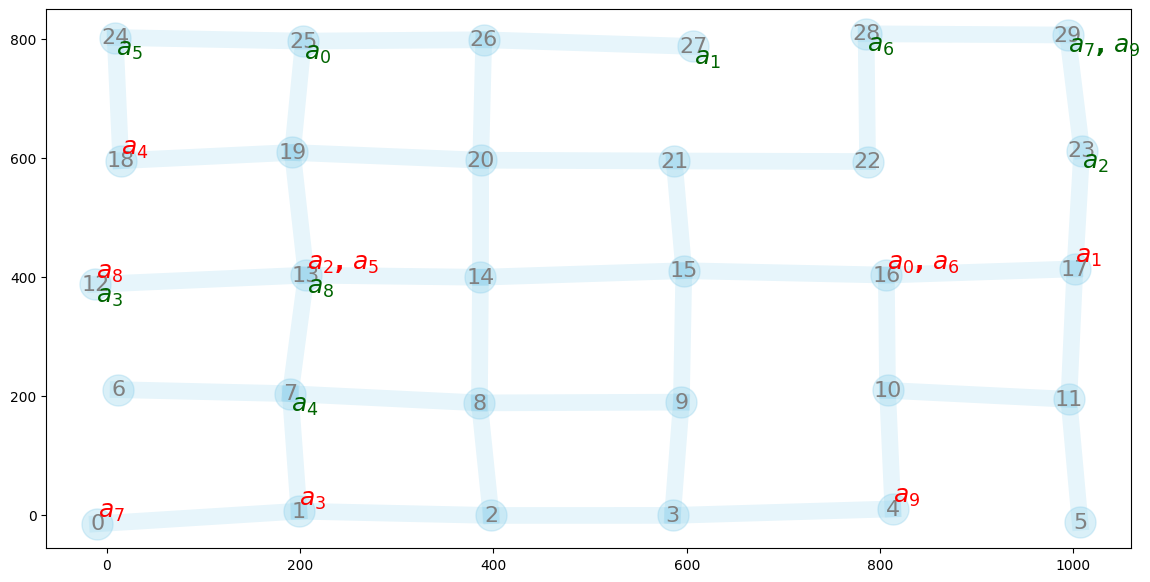

In [2]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 30
n_agents = 10
tolArray = np.random.uniform(5.0, 5.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':1000,
    'noise_factor':15
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.00,
    'missing_connections':0.05
}

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    grid_params, 
    seed=11, 
    offset_energy=1,
    printFlag=True)

# compute conflict cost
beta0=1e-8
gamma_t = 5
gamma_c = 7.5
coeff_t = 50
coeff_c = 5.0

# mars visualization
cmap = get_cmap('tab20')
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))}
createEnv.plotNetwork(mars=mars, figuresize=(14,7), routes=[], agent_colors=agent_colors, showEdgeLength=False)

# agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



In [3]:
# agent_0 = mars.agents[0]
# sched0_init = mars.sched_mat[0,:]
# lb0 = np.zeros(sched0_init.shape)
# ub0 = 100 * np.ones(lb0.shape)
# bounds = Bounds(lb0, ub0)

In [4]:
# beta_min = 1e-5
# beta_max = 1e3
# beta_grow = 3
# beta = beta_min
# beta_arr = []
# while beta <= beta_max:
#     beta_arr.append(beta)
#     beta = beta * beta_grow

In [5]:
# for i, b in enumerate(beta_arr):
#     res = minimize(
#         agent_0.getFreeEnergy_s_v1,
#         sched0_init,
#         args = (mars.dist_mat, b),
#         method='slsqp',
#         options={'disp':0},
#         bounds=bounds
#     )
#     sched0_init = res.x

#     print(f'beta:{b:.4e}\tfreeEnergy:{res.fun:.4f}')



In [6]:
# Pb = agent_0.getPathAssociations_v1(sched0_init, mars.dist_mat, beta=1e8)
# agent_0.calc_route_and_schedule(sched0_init, mars.dist_mat, Pb)
# r = agent_0.route
# s = agent_0.fin_sched
# print(f'agent {agent_0}\n route: {r} \t schedule : {np.round(s,2)}')

### Test the optimization for all the agents together

In [7]:
# # annealing
# sched_vec0 = mars.sched_mat.flatten()

# lb = np.ones(shape=sched_vec0.shape)*mars.t_start_min
# ub = np.ones(shape=sched_vec0.shape)*100.0
# print(f'agent start nodes {mars.agents[0].s}')
# print(f'init schedule vec {sched_vec0}')
# print(f'ub {ub}')
# print(f'lb {lb}')

# sched_bounds = [lb,ub]
# beta_lims = [1e-6,1]
# beta_grow = 1.5
# # opts = {'gtol':1e-4, 'verbose':0, 'maxiter':200}
# opts = {'disp':0}
# C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing_v1(beta_lims=beta_lims,
#                                             beta_grow=beta_grow,
#                                             sched_vec0=sched_vec0,
#                                             init_sched_bounds=sched_bounds,
#                                             optimize_opt=opts,
#                                             allowPrintAnneal=True,
#                                             allowPrintOptimize=False)

# # C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing(beta_lims=beta_lims,
# #                                             beta_grow=beta_grow,
# #                                             sched_vec0=sched_vec0,
# #                                             init_sched_bounds=sched_bounds,
# #                                             optimize_opt=opts,
# #                                             allowPrintAnneal=True,
# #                                             allowPrintOptimize=False)



In [8]:
# importlib.reload(createEnv)
# importlib.reload(flpoAgent)
# print('\nOptimization Results')
# print(f'initial schedule:{sched_vec0}')
# print(f'final schedule:\n{mars.sched_mat}')
# print(f'processing time:\n{mars.process_T}')
# print(f'cost:{C_arr[-1]}')

# agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)
# createEnv.plotNetwork(mars=mars, figuresize=(12,8), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False, plotPaths=True)
# # createEnv.plot_vehicle_routes(agent_routes, agent_schedules, mars.process_T, agent_colors)
# # createEnv.plot_waypoint_schedules(filter_wp_beta_data[-1], mars.sched_mat)
# createEnv.plot_waypoint_agent_schedules(
#     agent_routes, agent_schedules, mars.sched_mat, 
#     filter_wp_beta_data[-1], mars.process_T, agent_colors,
#     figuresize=(12,12))
# plt.figure(figsize=(8,4))
# plt.plot(np.log(beta_arr)/np.log(10), conflict_C_arr.sum(axis=1), marker='o', linewidth=2, color='red')
# plt.xlabel(rf'$\log\beta$', fontsize=14)
# plt.ylabel(rf'Cost', fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.grid()
# plt.show()
# # agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



### Write a code to solve MARS using CBF-CLF based appraoch

In [9]:
beta_min = 1e-5
beta_max = 1e1
beta_grow = 1.5
beta = beta_min
beta_arr = []
while beta <= beta_max:
    beta_arr.append(beta)
    beta = beta * beta_grow


T0 = np.ones((mars.n_agents, mars.n_waypoints))
for i in range(mars.n_agents):
    if i > 0:
        T0[i] = T0[i-1] + mars.tolArray + np.random.uniform(0,5, mars.tolArray.shape)


optimizer = {
    'name':'cbf_clf',
    'dt_init':0.01,
    'dt_min':1e-6,
    'dt_max':0.1,
    'Tf':20,
    'gamma':1,
    'alpha':2,
    'p':1,
    'stop_tol':0.05,
    'stop_tol_weight':np.array([1, 1, 1]),
    'verbose':0
}



In [10]:
active_waypoints = [29] #range(mars.n_waypoints)
T, F, Pb_a = mars.anneal(beta_arr, T0, active_waypoints=None, optimizer=optimizer, annealPrint=True)

TypeError: object of type 'NoneType' has no len()

In [11]:
import numpy as np
H = np.random.uniform(0,1,(3,3))
H

array([[0.62308574, 0.55505367, 0.10211644],
       [0.37608294, 0.5998479 , 0.39268497],
       [0.50654508, 0.47464993, 0.23523687]])

In [12]:
A = np.ones(H.shape)
A

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [13]:
A[H>=0] = 0
A

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [14]:
rho = A.sum(axis=0)
rho

array([0., 0., 0.])

In [15]:
list(np.where(rho > 0)[0])

[]

In [11]:
mars.sched_mat = T
agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)


route v0: [25, 19, 20, 21, 15, 16], schedule: [ 0.    5.03 10.24 15.62 20.55 26.19]
route v1: [27, 26, 20, 21, 15, 16, 17], schedule: [2.000e-02 6.470e+00 1.261e+01 1.845e+01 2.412e+01 3.026e+01 3.619e+01]
route v2: [23, 17, 16, 15, 14, 13], schedule: [3.000e-02 6.300e+00 1.242e+01 1.905e+01 2.564e+01 3.133e+01]
route v3: [12, 13, 7, 1], schedule: [ 0.04  6.92 13.2  19.4 ]
route v4: [7, 13, 19, 18], schedule: [ 0.05  5.48 11.09 15.93]
route v5: [24, 25, 19, 13], schedule: [ 0.06  6.26 12.22 18.77]
route v6: [28, 22, 21, 15, 16], schedule: [ 0.07  6.01 11.53 16.63 22.41]
route v7: [29, 23, 17, 16, 15, 14, 13, 7, 1, 0], schedule: [ 0.12  5.56 11.13 16.57 22.52 28.45 33.6  39.27 44.99 51.08]
route v8: [13, 12], schedule: [0.11 6.14]
route v9: [29, 23, 17, 16, 10, 4], schedule: [10.13 16.63 23.26 29.76 36.17 42.76]


In [1]:
# mars visualization
cmap = get_cmap('tab20')
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))}
createEnv.plotNetwork(mars=mars, figuresize=(14,6), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False)


NameError: name 'get_cmap' is not defined

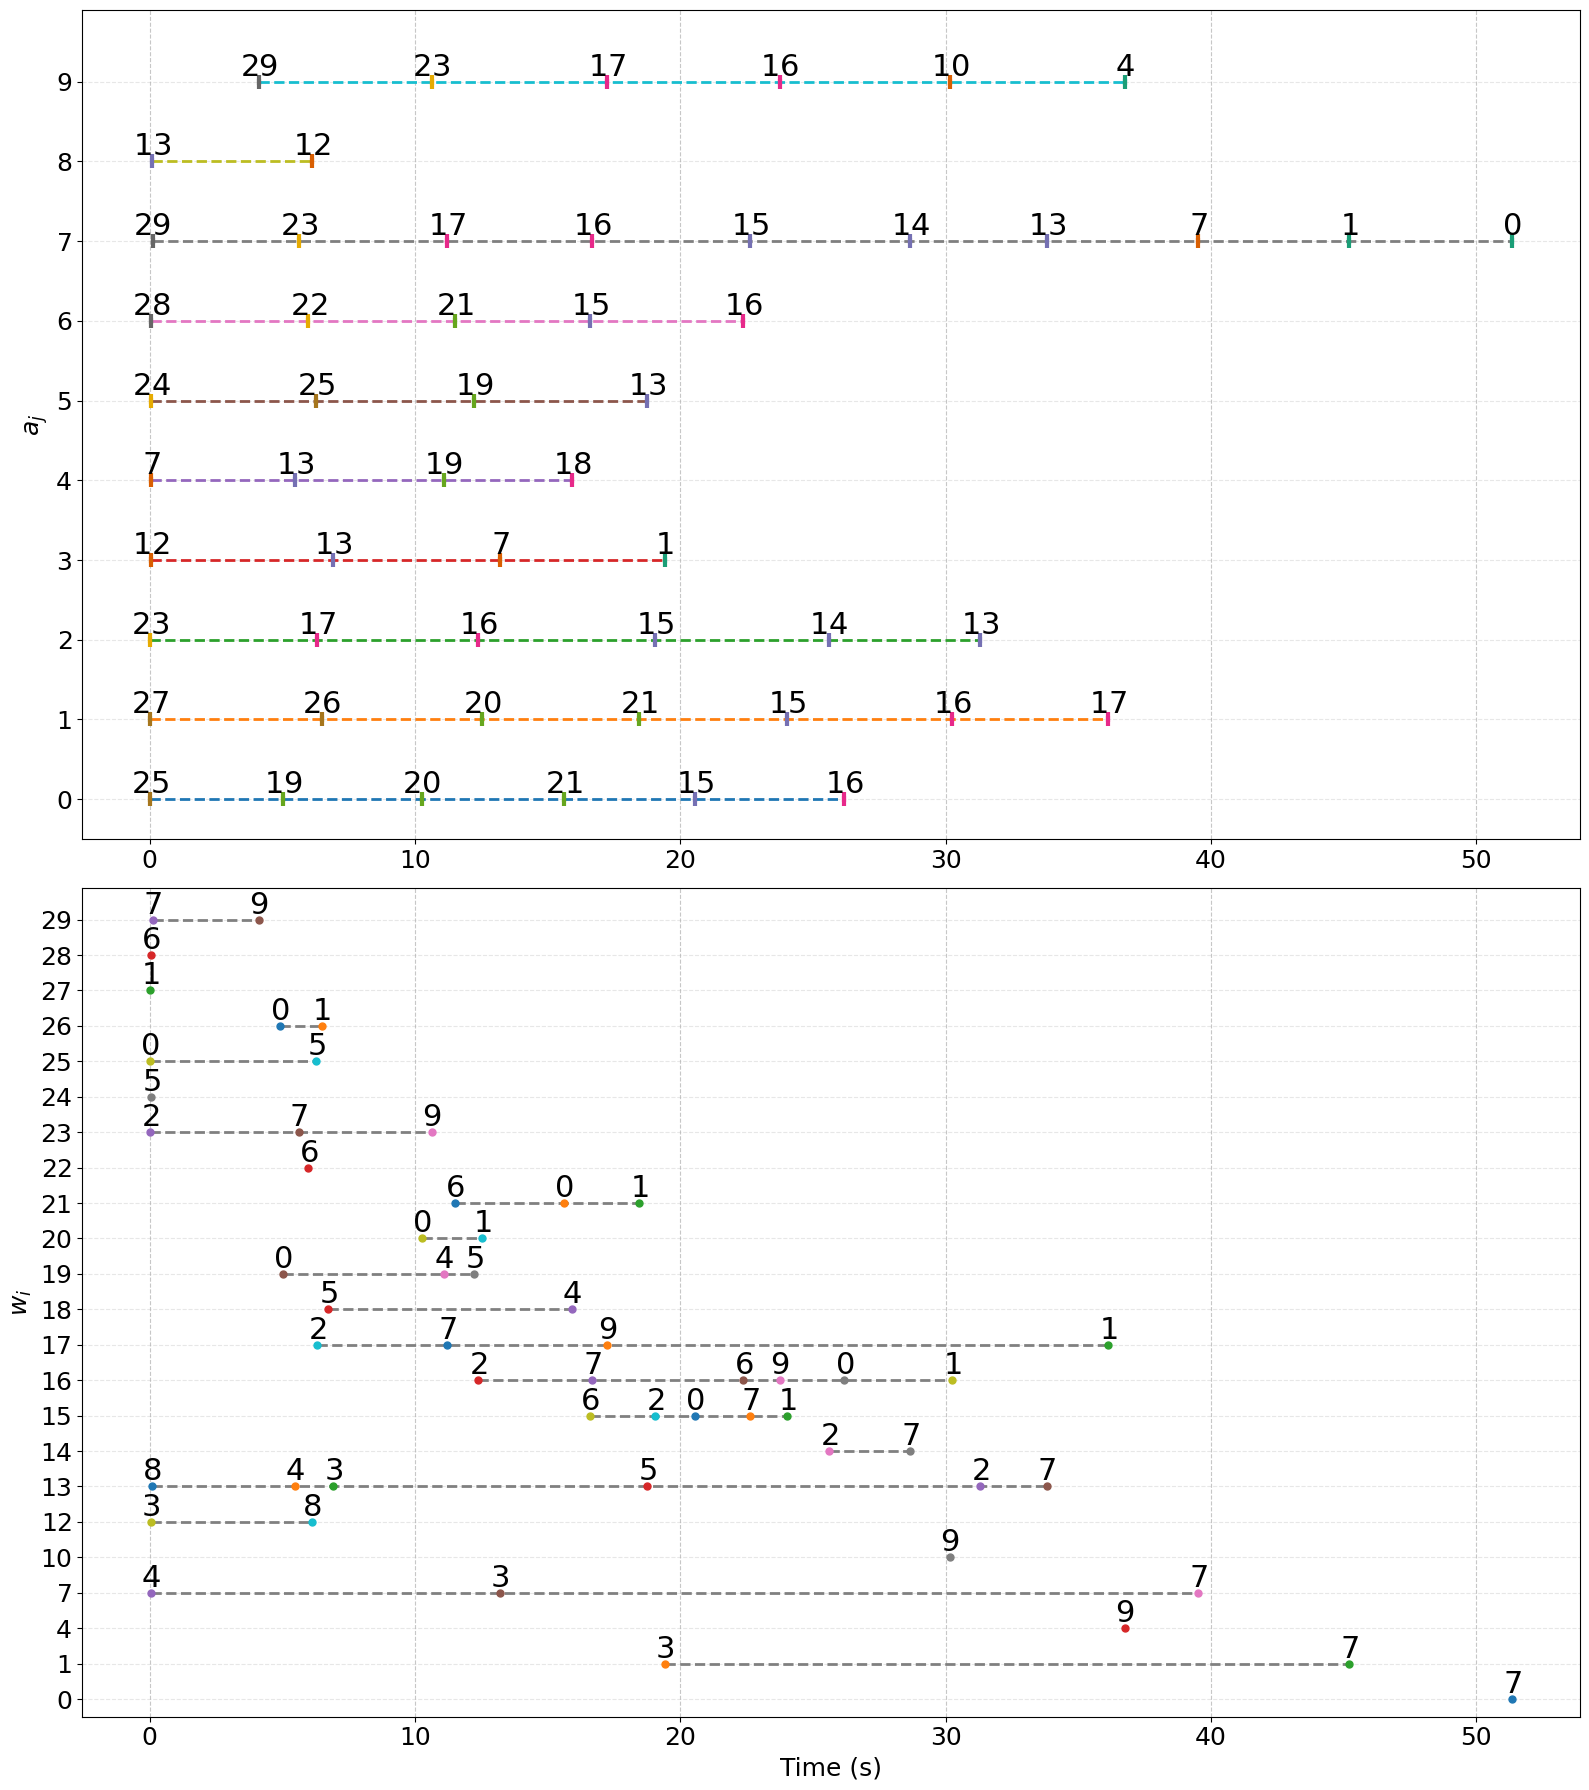

In [13]:
reach_mat = mars.calc_agent_reach_mat_v1(mars.sched_mat, beta_arr[-1])
filter_wp = np.ones(shape=reach_mat.shape)
filter_wp[reach_mat <= 1.0e-10] = 0.0
createEnv.plot_waypoint_agent_schedules(agent_routes, agent_schedules, mars.sched_mat, filter_wp, mars.process_T, agent_colors, figuresize=(16,18))